# Customer Intelligence System

**Assignment 3

**Source:** https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data




## Section 1 — Importing Libraries

In [52]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# for splitting data and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# classification models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# clustering algorithms
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors

# to reduce dimensions so we can plot things in 2D
from sklearn.decomposition import PCA

# metrics to check how good our models are
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix,silhouette_score


import gc

# sns.set_theme(style='whitegrid', palette='muted')
# plt.rcParams['figure.figsize'] = (10, 6)
# plt.rcParams['font.size'] = 11


## Section 2 — Loading the Dataset


In [53]:

df = pd.read_csv('Country-data.csv')

print(f"Shape: {df.shape}")
print(f"  {df.shape[0]} countries | {df.shape[1]} columns")
print("\nColumn names:", df.columns)
df.head()

Shape: (167, 10)
  167 countries | 10 columns

Column names: Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [54]:
# check data types and null counts

df.info()
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Total missing values: 0


In [55]:
# basic statistics for all numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## Section 3 — Feature Reference Table

Before diving into analysis, it's useful to know what each column actually means. I made a quick reference table for that.

In [6]:
# feature descriptions so we know what we're working with
feature_descriptions = {
    'country'   : 'Name of the country (identifier, not used for modelling)',
    'child_mort': 'Deaths of children under 5 years per 1000 live births',
    'exports'   : 'Exports of goods/services as % of GDP',
    'health'    : 'Total government spending on healthcare as % of GDP',
    'imports'   : 'Imports of goods/services as % of GDP',
    'income'    : 'Net income per person in USD',
    'inflation' : 'Annual inflation rate (%)',
    'life_expec': 'Average life expectancy in years',
    'total_fer' : 'Average number of children per woman',
    'gdpp'      : 'GDP per capita — total economic output per person (USD)'
}

ref_table = pd.DataFrame(list(feature_descriptions.items()), columns=['Feature', 'What it means'])
print("Feature Reference:")
print(ref_table.to_string(index=False))

Feature Reference:
   Feature                                            What it means
   country Name of the country (identifier, not used for modelling)
child_mort    Deaths of children under 5 years per 1000 live births
   exports                    Exports of goods/services as % of GDP
    health      Total government spending on healthcare as % of GDP
   imports                    Imports of goods/services as % of GDP
    income                             Net income per person in USD
 inflation                                Annual inflation rate (%)
life_expec                         Average life expectancy in years
 total_fer                     Average number of children per woman
      gdpp  GDP per capita — total economic output per person (USD)


## Section 4 — Exploratory Data Analysis



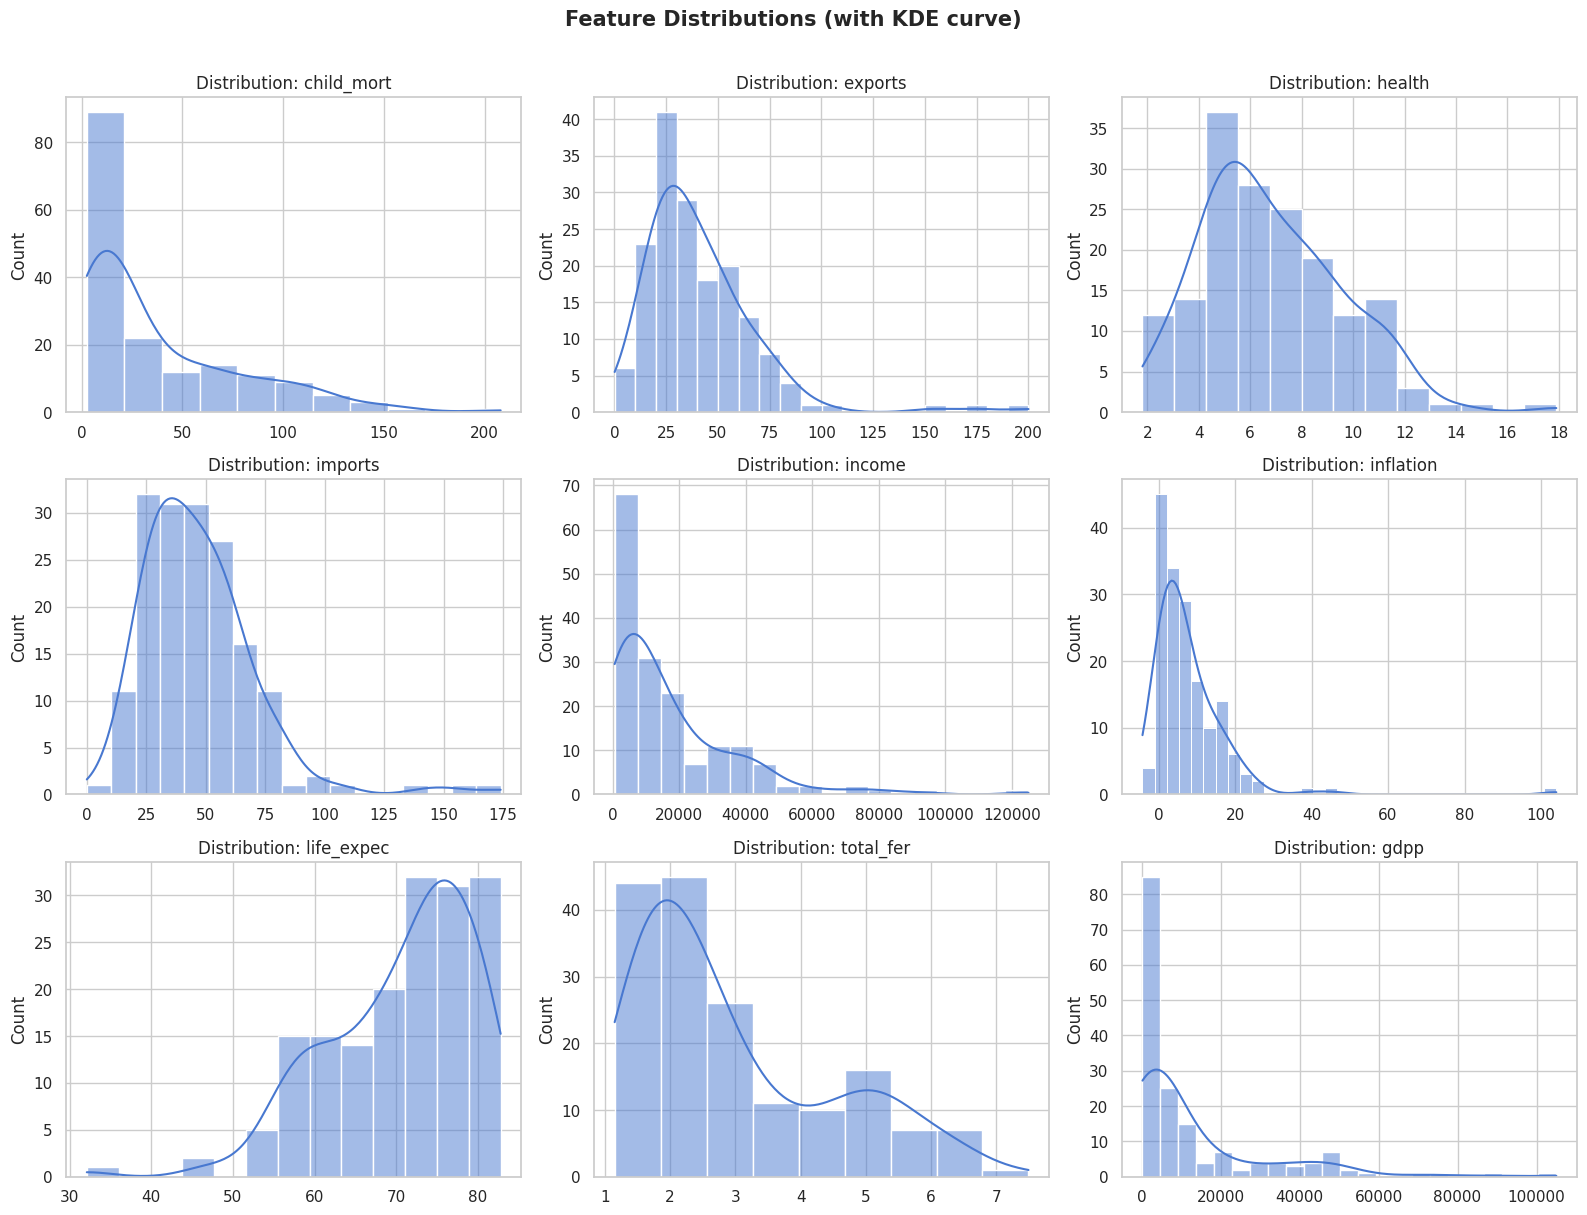

In [56]:
# numeric feature
num_cols = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

# plot histogram +\
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions (with KDE curve)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


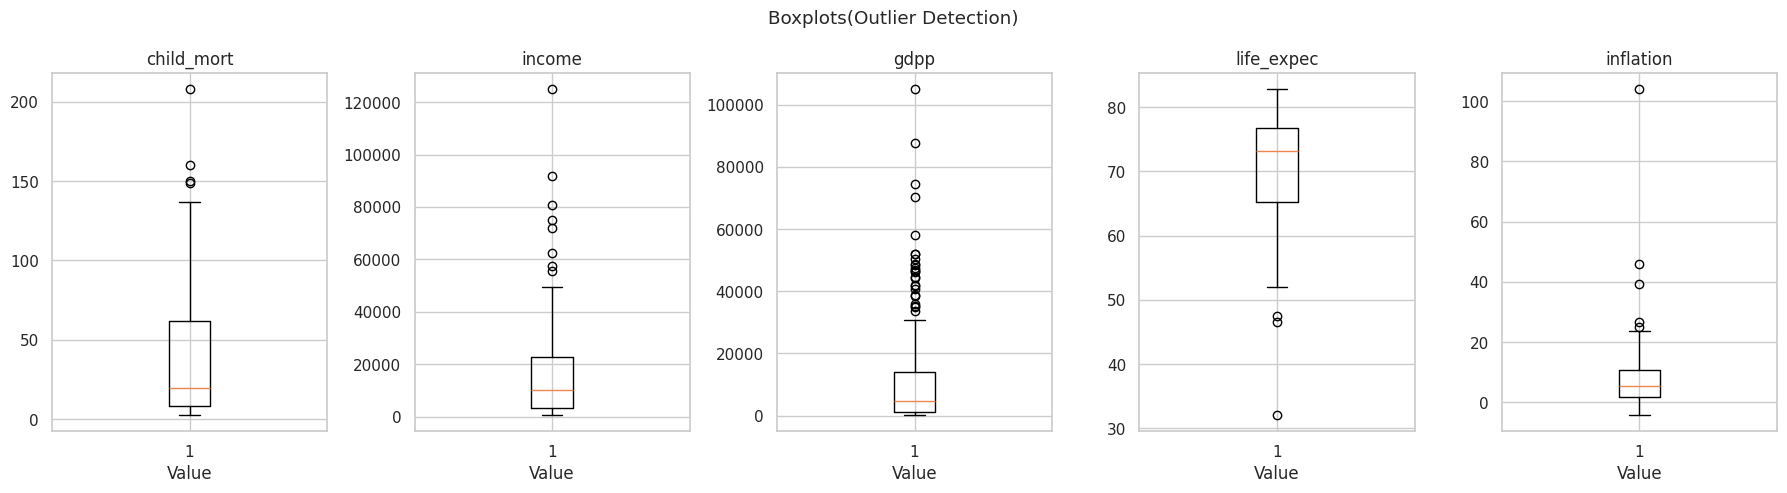

In [57]:
#  outliers
key_cols = ['child_mort', 'income', 'gdpp', 'life_expec', 'inflation']

fig, axes = plt.subplots(1, len(key_cols), figsize=(18, 5))
for idx, col in enumerate(key_cols):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(col)
    axes[idx].set_xlabel('Value')

plt.suptitle('Boxplots(Outlier Detection)')
plt.tight_layout()

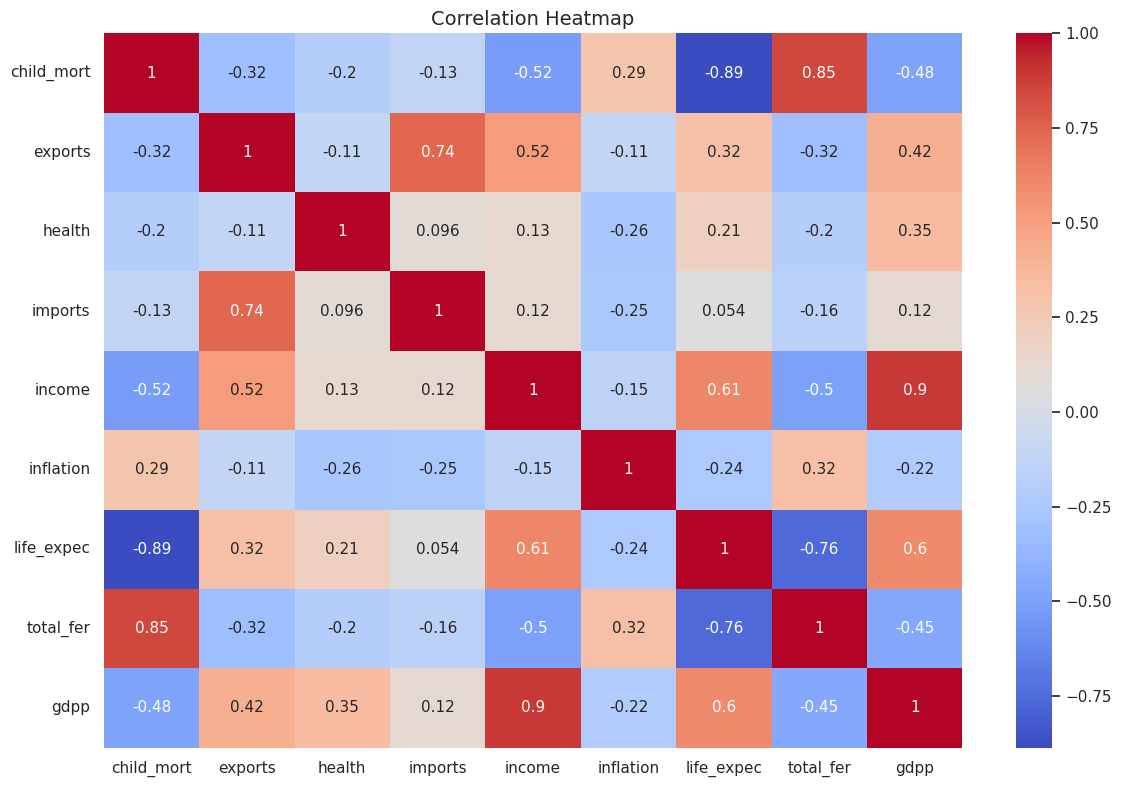

In [58]:
#corelation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop('country', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

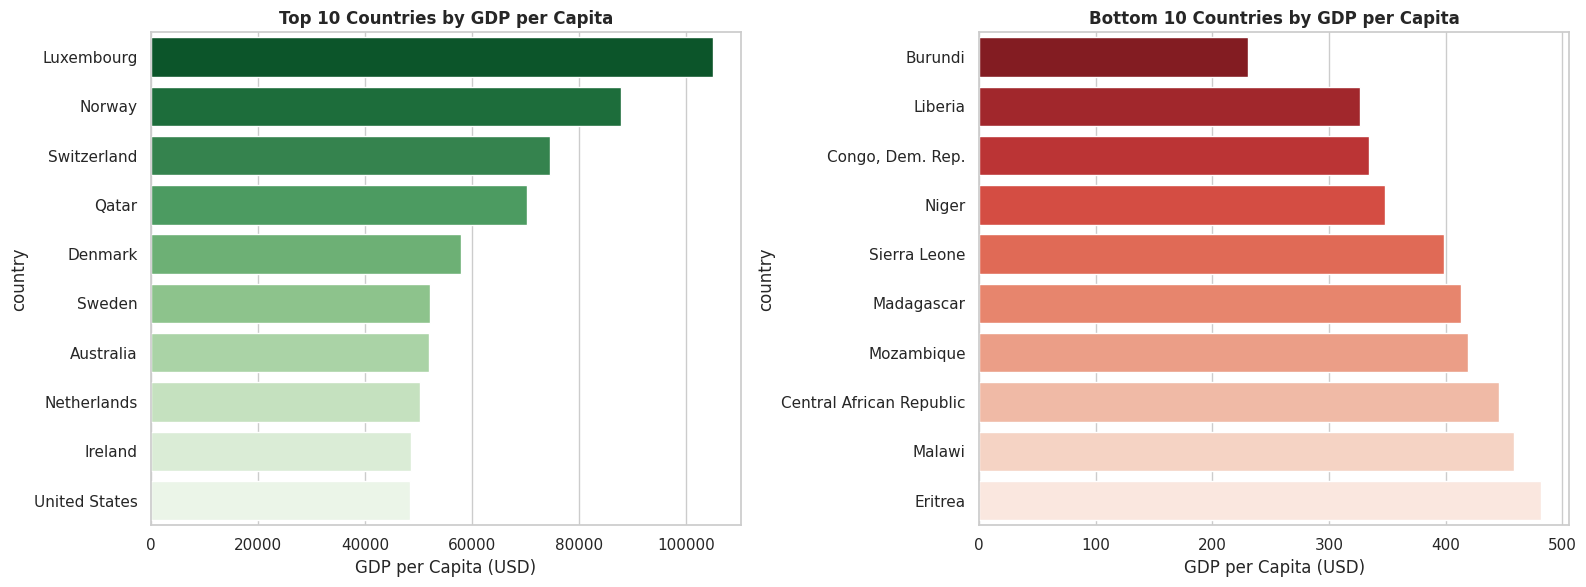

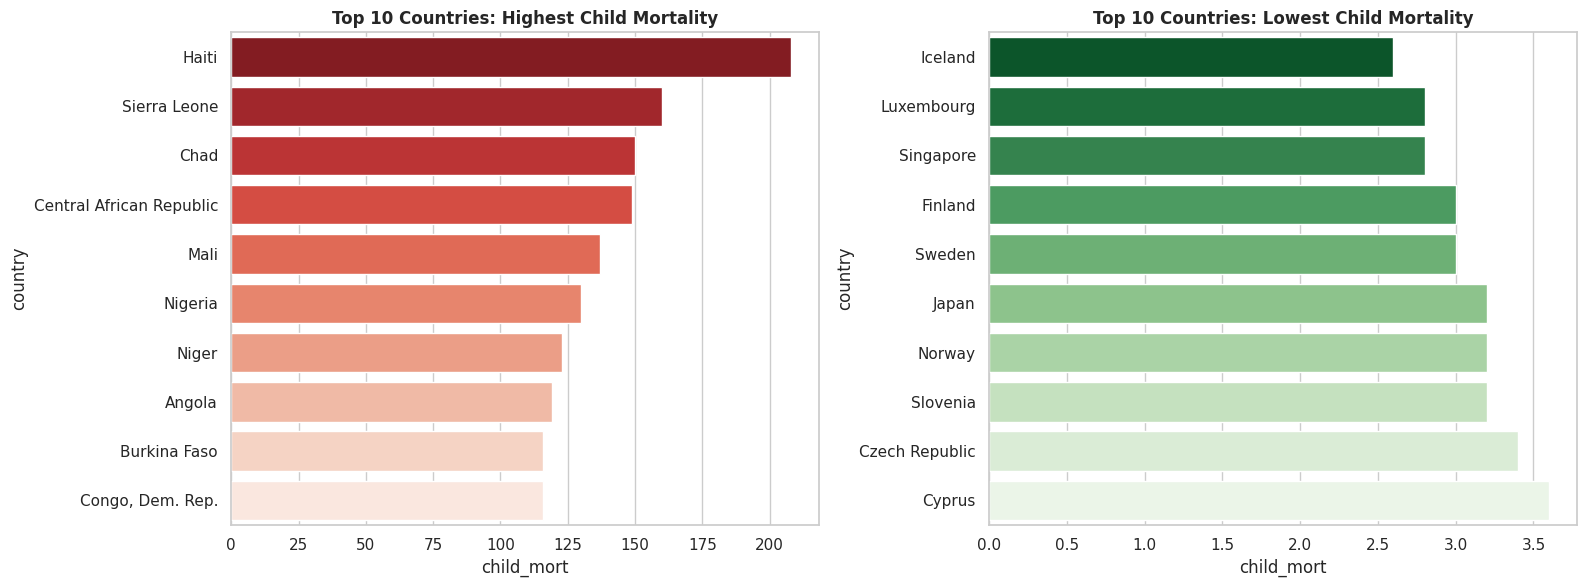

In [59]:
#  countries wise analysis — top and bottom GDP
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_gdp = df.nlargest(10, 'gdpp')
sns.barplot(data=top_gdp, x='gdpp', y='country', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Countries by GDP per Capita', fontweight='bold')
axes[0].set_xlabel('GDP per Capita (USD)')

bot_gdp = df.nsmallest(10, 'gdpp')
sns.barplot(data=bot_gdp, x='gdpp', y='country', ax=axes[1], palette='Reds_r')
axes[1].set_title('Bottom 10 Countries by GDP per Capita', fontweight='bold')
axes[1].set_xlabel('GDP per Capita (USD)')

plt.tight_layout()
plt.show()

# child mortality
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_cm = df.nlargest(10, 'child_mort')
sns.barplot(data=top_cm, x='child_mort', y='country', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Countries: Highest Child Mortality', fontweight='bold')

bot_cm = df.nsmallest(10, 'child_mort')
sns.barplot(data=bot_cm, x='child_mort', y='country', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Countries: Lowest Child Mortality', fontweight='bold')

plt.tight_layout()
plt.show()


## Section 5 — Data Preprocessing




In [61]:
# make a copy so the original df stays intact
df_clean = df.copy()

# IQR capping — clips extreme outliers to upper/lower bounds instead of removing
# I prefer this over dropping rows because our dataset is small (only 167 countries)
for col in num_cols:
    q1  = df_clean[col].quantile(0.25)
    q3  = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    low_bound  = q1 - 1.5 * iqr
    high_bound = q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(low_bound, high_bound)

print("Outlier capping done using IQR method")
print(f"Dataset shape is still: {df_clean.shape}")

Outlier capping done using IQR method
Dataset shape is still: (167, 10)


In [62]:
# now apply StandardScaler to bring all features to the same range
# this is  important for distance-based models like K-Means and DBSCAN
# without scaling, a feature like gdpp  100 to 100000 would dominate

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[num_cols])

X_scaled_df = pd.DataFrame(X_scaled, columns=num_cols)


print(f"  Mean (should be ~0): {X_scaled.mean():.6f}")
print(f"  Std  (should be ~1): {X_scaled.std():.6f}")
X_scaled_df.head(3)

  Mean (should be ~0): 0.000000
  Std  (should be ~1): 1.000000


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.369802,-1.391107,0.296013,-0.047444,-0.943936,0.355270,-1.702225,1.915276,-0.846341
1,-0.550464,-0.543547,-0.091190,0.135021,-0.395181,-0.385208,0.663321,-0.862779,-0.540827
2,-0.271295,-0.053846,-0.985893,-0.713196,-0.199291,1.351551,0.686859,-0.036691,-0.508868


## Section 6 — K-Means Clustering



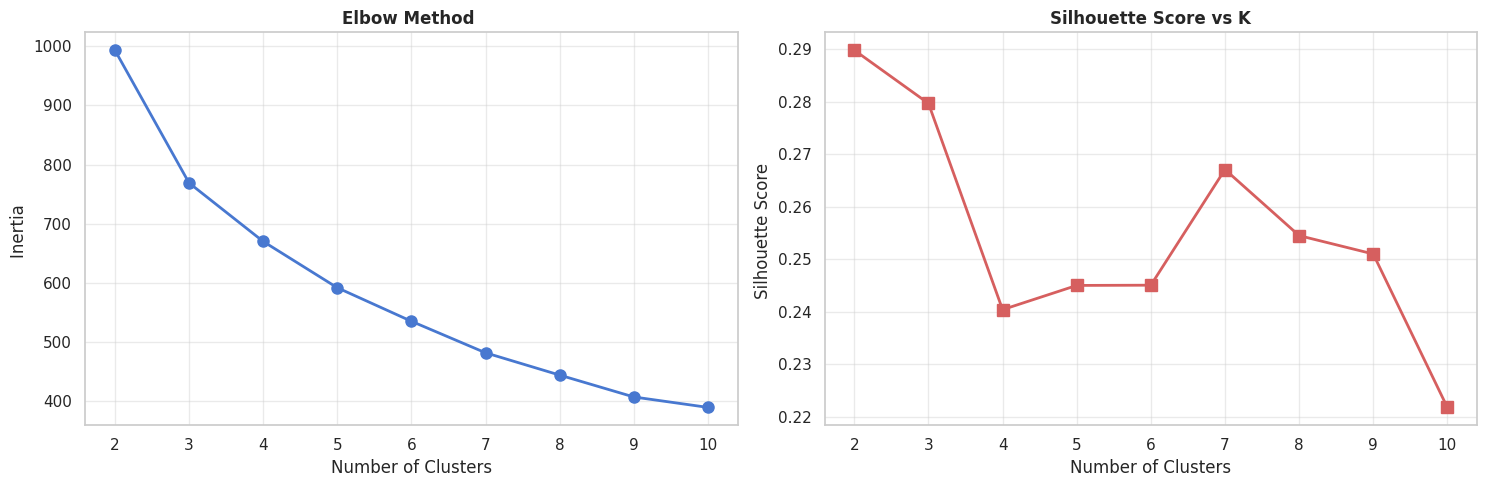

Best K by Silhouette Score: 2
Silhouette Score at K=2: 0.2898


In [63]:

inertia_list = []
sil_list     = []
k_values     = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    preds = km.fit_predict(X_scaled)
    inertia_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_scaled, preds))

# plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(k_values, inertia_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method ', fontweight='bold')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia ')
axes[0].grid(True, alpha=0.4)

axes[1].plot(k_values, sil_list, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score ')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

best_k = list(k_values)[np.argmax(sil_list)]
print(f"Best K by Silhouette Score: {best_k}")
print(f"Silhouette Score at K={best_k}: {max(sil_list):.4f}")

In [64]:

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

km_sil_score = silhouette_score(X_scaled, df_clean['KMeans_Cluster'])

print(f"K-Means trained with K = {best_k}")
print(f"Silhouette Score: {km_sil_score:.4f}")
print("\nCluster size distribution:")
print(df_clean['KMeans_Cluster'].value_counts().sort_index())

K-Means trained with K = 2
Silhouette Score: 0.2898

Cluster size distribution:
KMeans_Cluster
0    98
1    69
Name: count, dtype: int64


## Section 7 — Dimensionality Reduction with PCA



In [65]:
# PCA — reduce 9 features to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"PCA Component 1 explains: {explained[0]*100:.2f}% of variance")
print(f"PCA Component 2 explains: {explained[1]*100:.2f}% of variance")
print(f"Total variance captured : {explained.sum()*100:.2f}%")

PCA Component 1 explains: 48.89% of variance
PCA Component 2 explains: 16.45% of variance
Total variance captured : 65.35%


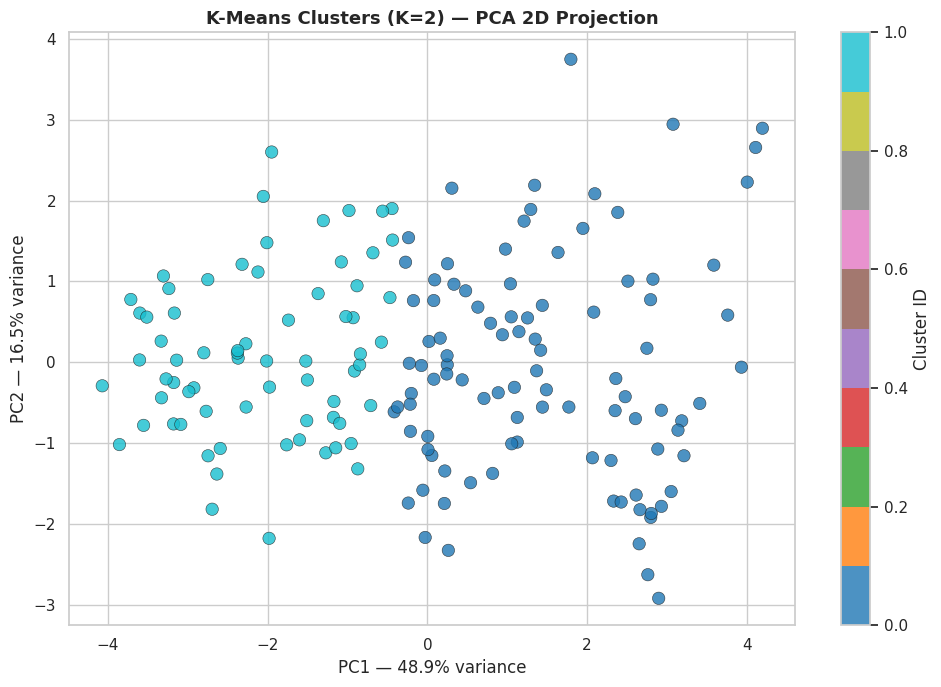

In [66]:
# scatter plot of K-Means clusters in 2D PCA space
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_clean['KMeans_Cluster'],
                      cmap='tab10', s=80, alpha=0.8,
                      edgecolors='k', linewidths=0.4)
plt.colorbar(scatter, label='Cluster ID')
plt.title(f'K-Means Clusters (K={best_k}) — PCA 2D Projection',
          fontweight='bold', fontsize=13)
plt.xlabel(f'PC1 — {explained[0]*100:.1f}% variance')
plt.ylabel(f'PC2 — {explained[1]*100:.1f}% variance')
plt.tight_layout()
plt.show()


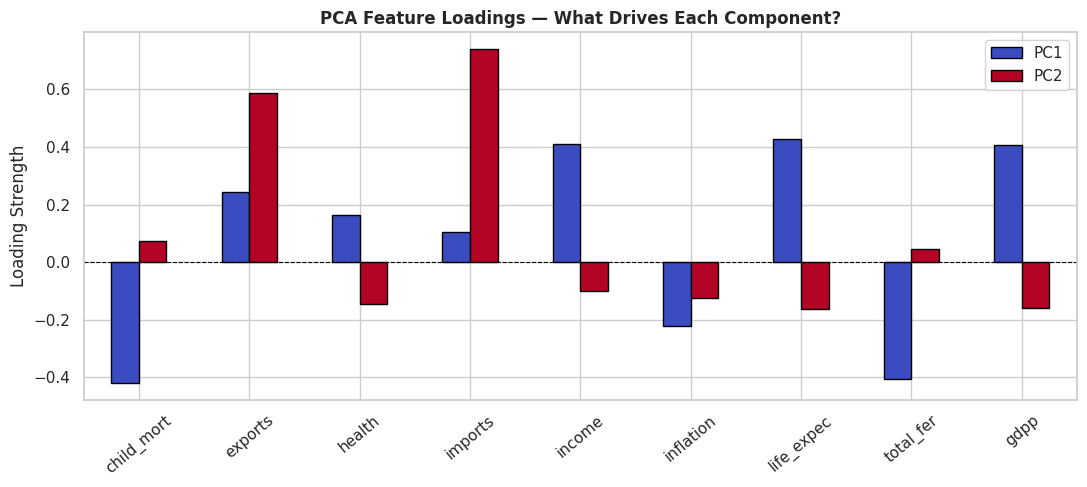

In [67]:
# PCA loading plot — which features drive each component?
loadings = pd.DataFrame(pca.components_.T,
                         index=num_cols,
                         columns=['PC1', 'PC2'])

loadings.plot(kind='bar', figsize=(11, 5), colormap='coolwarm', edgecolor='black')
plt.title('PCA Feature Loadings — What Drives Each Component?', fontweight='bold')
plt.ylabel('Loading Strength')
plt.xticks(rotation=40)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()


Observation: PC1 is mainly driven by life_expec, child_mort, gdpp, income\
PC2 is more about exports and imports — trade activity of a country

## Section 8 — DBSCAN Clustering


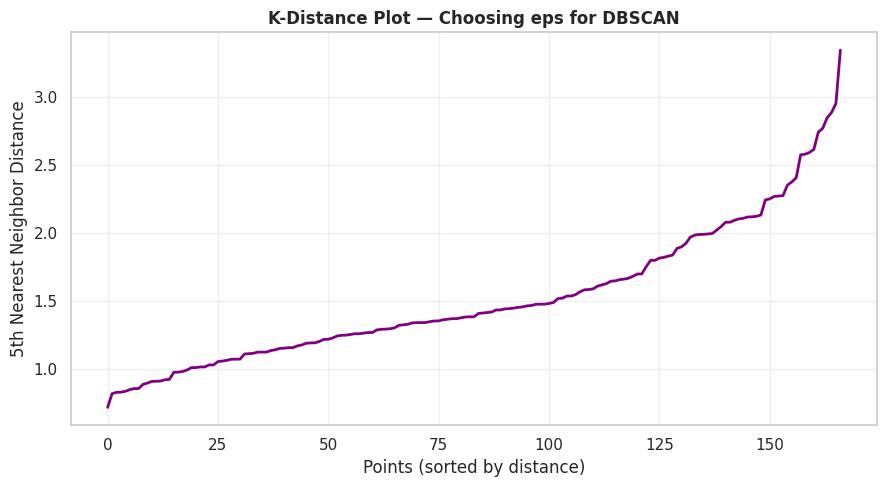

In [68]:
# K-distance plot — helps pick the right eps for DBSCAN
# we look at how far each point is from its 5th nearest neighbor
# the 'elbow' in the graph is a good eps value

nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
dist_sorted  = np.sort(distances[:, 4])  # 5th nearest neighbor distance

plt.figure(figsize=(9, 5))
plt.plot(dist_sorted, color='purple', linewidth=2)
plt.xlabel('Points (sorted by distance)')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Plot — Choosing eps for DBSCAN', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [69]:
# run DBSCAN with chosen eps
# I'm using eps=2.5 based on the elbow
dbscan_model = DBSCAN(eps=2.5, min_samples=5)
df_clean['DBSCAN_Cluster'] = dbscan_model.fit_predict(X_scaled)

n_db_clusters = len(set(df_clean['DBSCAN_Cluster'])) - (1 if -1 in df_clean['DBSCAN_Cluster'].values else 0)
n_noise       = (df_clean['DBSCAN_Cluster'] == -1).sum()

print("DBSCAN Results:")
print(f"  Clusters Found : {n_db_clusters}")
print(f"  Noise Points   : {n_noise} (label = -1)")
print("\nCluster Distribution:")
print(df_clean['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN Results:
  Clusters Found : 1
  Noise Points   : 1 (label = -1)

Cluster Distribution:
DBSCAN_Cluster
-1      1
 0    166
Name: count, dtype: int64


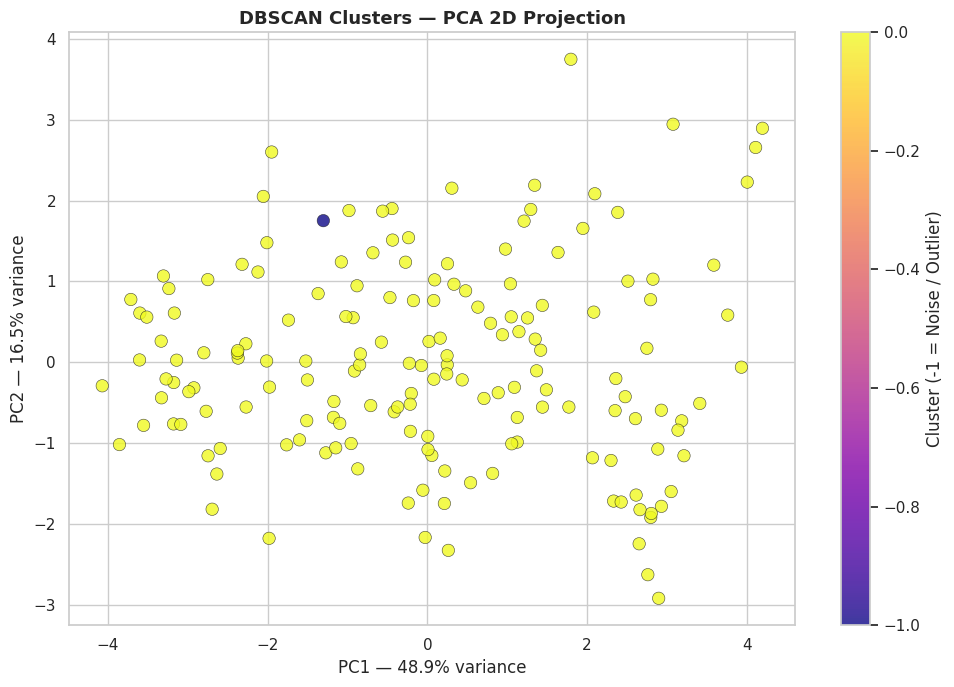

In [70]:
# visualize DBSCAN result in PCA 2D space
plt.figure(figsize=(10, 7))
scatter2 = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                        c=df_clean['DBSCAN_Cluster'],
                        cmap='plasma', s=80, alpha=0.8,
                        edgecolors='k', linewidths=0.4)
plt.colorbar(scatter2, label='Cluster (-1 = Noise / Outlier)')
plt.title('DBSCAN Clusters — PCA 2D Projection', fontweight='bold', fontsize=13)
plt.xlabel(f'PC1 — {explained[0]*100:.1f}% variance')
plt.ylabel(f'PC2 — {explained[1]*100:.1f}% variance')
plt.tight_layout()
plt.show()


## Section 9 — Comparing K-Means vs DBSCAN

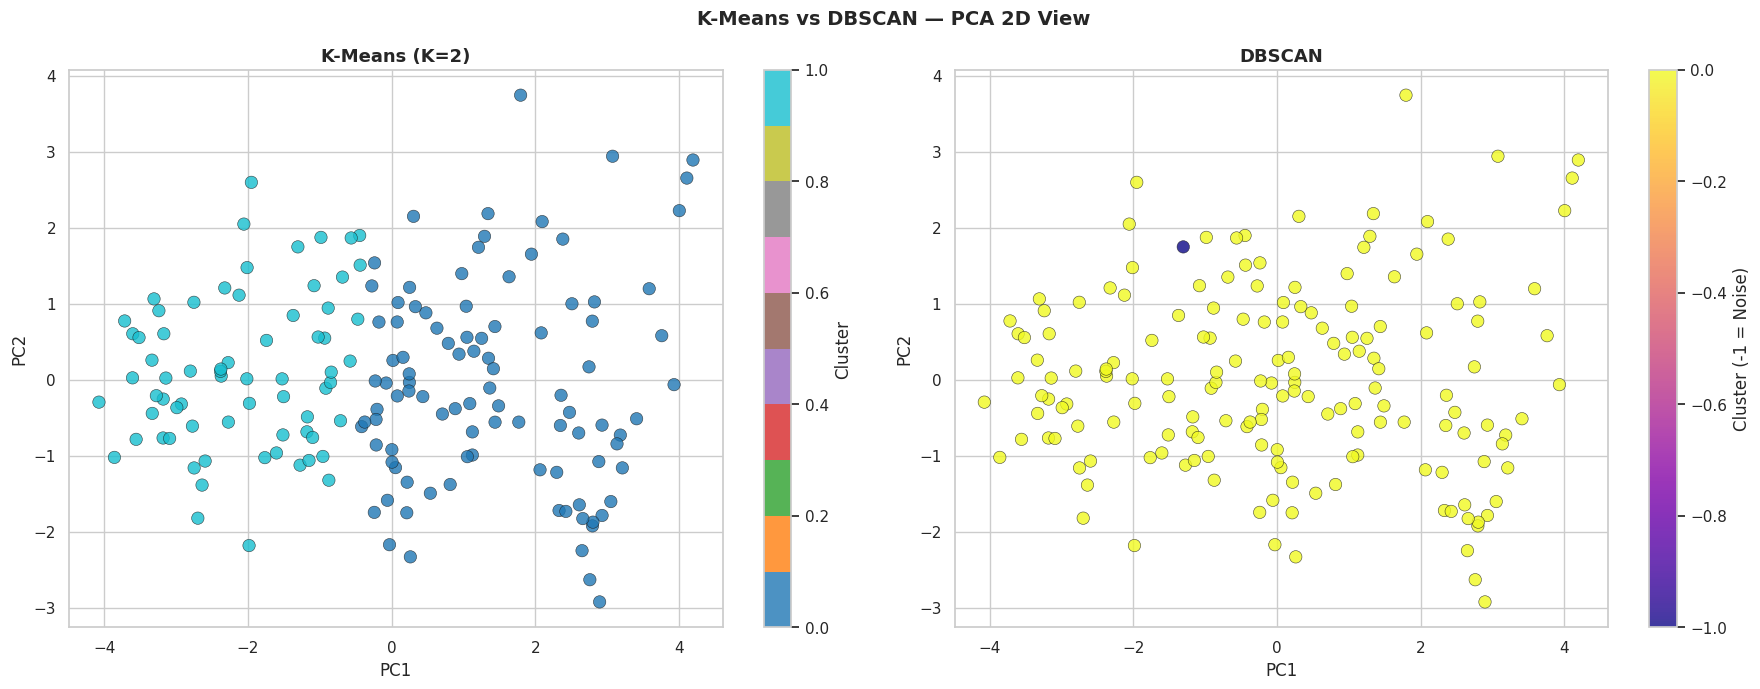

In [71]:
# side-by-side comparison of both clustering methods
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# K-Means
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_clean['KMeans_Cluster'], cmap='tab10',
                      s=80, alpha=0.8, edgecolors='k', linewidths=0.4)
axes[0].set_title(f'K-Means (K={best_k})', fontweight='bold', fontsize=13)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

# DBSCAN
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_clean['DBSCAN_Cluster'], cmap='plasma',
                      s=80, alpha=0.8, edgecolors='k', linewidths=0.4)
axes[1].set_title('DBSCAN', fontweight='bold', fontsize=13)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='Cluster (-1 = Noise)')

plt.suptitle('K-Means vs DBSCAN — PCA 2D View', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [72]:
# silhouette score comparison table
mask_db = df_clean['DBSCAN_Cluster'] != -1
if mask_db.sum() > 1 and len(df_clean.loc[mask_db, 'DBSCAN_Cluster'].unique()) > 1:
    db_sil_score = silhouette_score(X_scaled[mask_db], df_clean.loc[mask_db, 'DBSCAN_Cluster'])
    db_sil_str   = str(round(db_sil_score, 4))
else:
    db_sil_str = 'N/A'

comparison_df = pd.DataFrame({
    'Algorithm'        : ['K-Means', 'DBSCAN'],
    'Clusters Found'   : [best_k, n_db_clusters],
    'Silhouette Score' : [round(km_sil_score, 4), db_sil_str],
    'Noise Points'     : ['0', str(n_noise)]
})

print("Clustering Algorithm Comparison:")
print(comparison_df.to_string(index=False))

Clustering Algorithm Comparison:
Algorithm  Clusters Found Silhouette Score Noise Points
  K-Means               2           0.2898            0
   DBSCAN               1              N/A            1


## Section 10 — Cluster Profiling and Segmentation Insights


In [73]:
# average feature values for each K-Means cluster
cluster_profiles = df_clean.groupby('KMeans_Cluster')[num_cols].mean().round(2)

print("Cluster Profiles (Mean Values per Cluster):")
cluster_profiles

Cluster Profiles (Mean Values per Cluster):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,12.17,46.23,7.32,47.6,24111.02,5.11,76.52,1.94,16236.02
1,73.95,30.04,6.04,43.4,4290.19,9.85,62.35,4.37,1993.25


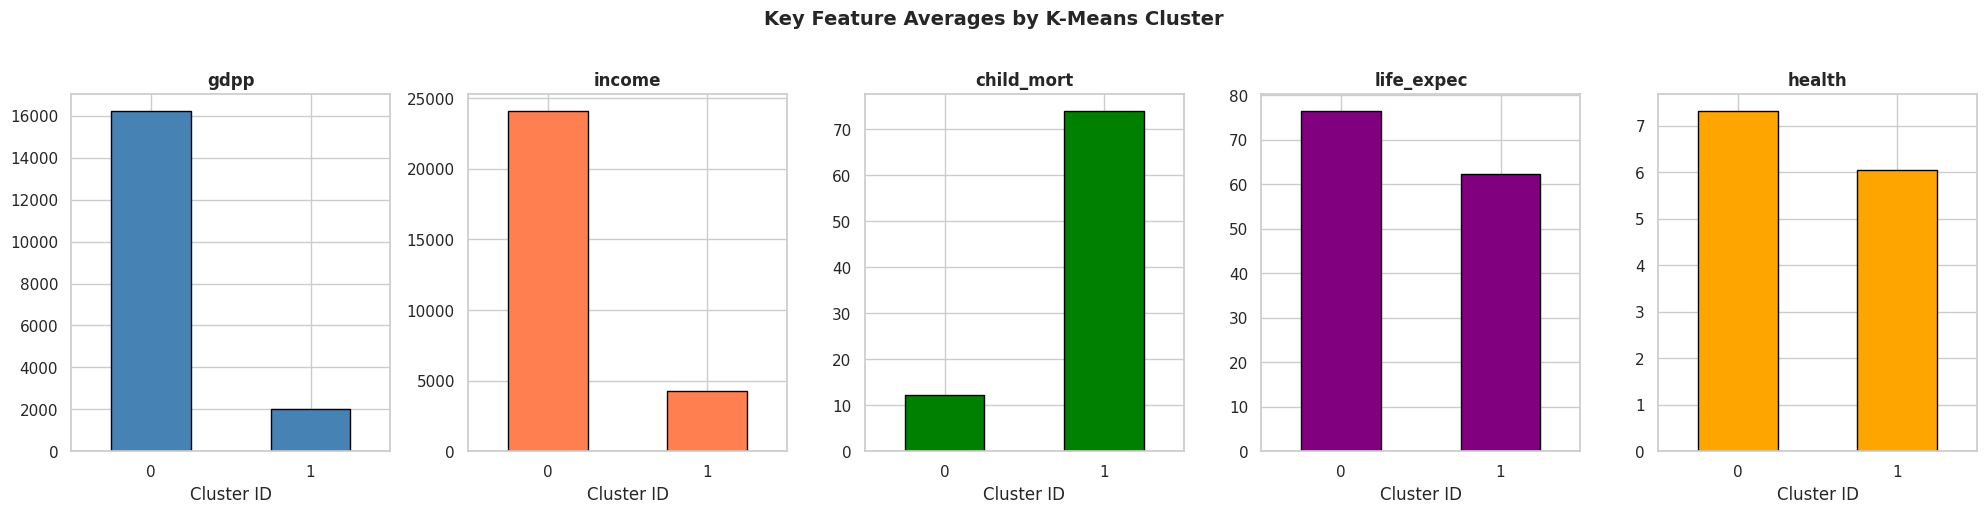

In [74]:
# bar charts for key features across clusters
key_display_cols = ['gdpp', 'income', 'child_mort', 'life_expec', 'health']
bar_colors       = ['steelblue', 'coral', 'green', 'purple', 'orange']

fig, axes = plt.subplots(1, len(key_display_cols), figsize=(20, 5))

for i, col in enumerate(key_display_cols):
    cluster_profiles[col].plot(kind='bar', ax=axes[i],
                               color=bar_colors[i], edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Cluster ID')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Key Feature Averages by K-Means Cluster', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [75]:
# assign meaningful labels based on GDP, life expectancy and child mortality
segment_names = {}
for cid in range(best_k):
    gdpp_val = cluster_profiles.loc[cid, 'gdpp']
    le_val   = cluster_profiles.loc[cid, 'life_expec']
    cm_val   = cluster_profiles.loc[cid, 'child_mort']

    if gdpp_val > 15000 and le_val > 70 and cm_val < 30:
        segment_names[cid] = 'Developed'
    elif gdpp_val > 5000:
        segment_names[cid] = 'Developing'
    else:
        segment_names[cid] = 'Underdeveloped'

df_clean['Segment'] = df_clean['KMeans_Cluster'].map(segment_names)

print("Segment Labels Assigned:")
for k, v in segment_names.items():
    print(f"   Cluster {k}  -->  {v}")

print("\nCountries per Segment:")
print(df_clean['Segment'].value_counts())

Segment Labels Assigned:
   Cluster 0  -->  Developed
   Cluster 1  -->  Underdeveloped

Countries per Segment:
Segment
Developed         98
Underdeveloped    69
Name: count, dtype: int64


In [76]:
# show sample countries from each segment
print("Sample Countries per Segment:\n")
for seg in df_clean['Segment'].unique():
    sample = df_clean[df_clean['Segment'] == seg]['country'].values[:10]
    print(f"  {seg}:")
    print(f"    {', '.join(sample)}")

Sample Countries per Segment:

  Underdeveloped:
    Afghanistan, Angola, Bangladesh, Benin, Bolivia, Botswana, Burkina Faso, Burundi, Cambodia, Cameroon

  Developed:
    Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Australia, Austria, Azerbaijan, Bahamas, Bahrain



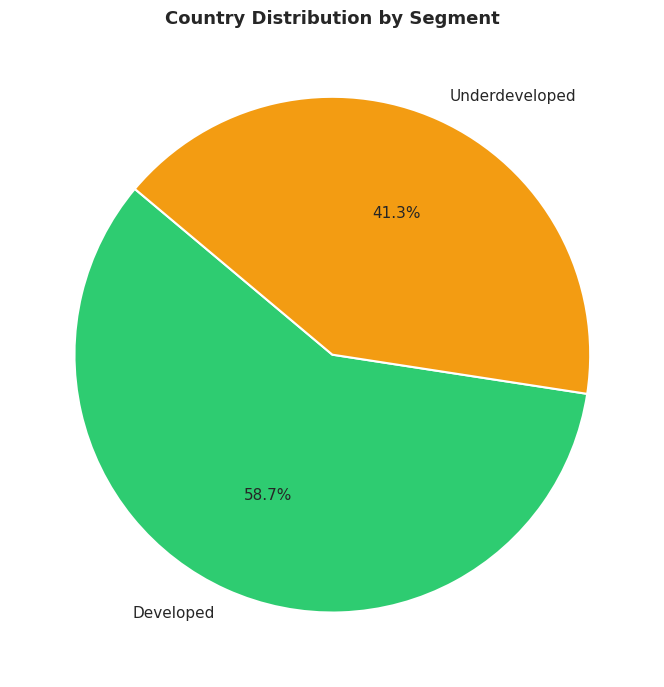

In [77]:
# segment count pie chart
seg_counts = df_clean['Segment'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(seg_counts.values, labels=seg_counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=['#2ecc71', '#f39c12', '#e74c3c'],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Country Distribution by Segment', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Section 11 — Preparing for Classification

We'll now use the cluster labels as our target variable and train classification models to predict which segment a country belongs to. This is the bridge between unsupervised and supervised learning.

In [78]:
# encode segment labels to numbers
le_encoder = LabelEncoder()
df_clean['Target'] = le_encoder.fit_transform(df_clean['Segment'])

print("Label Encoding:")
for idx, cls in enumerate(le_encoder.classes_):
    print(f"   {idx}  ==>  {cls}")

print(f"\nTarget value counts:\n{df_clean['Target'].value_counts()}")

Label Encoding:
   0  ==>  Developed
   1  ==>  Underdeveloped

Target value counts:
Target
0    98
1    69
Name: count, dtype: int64


In [80]:

X = X_scaled
y = df_clean['Target'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train/Test Split Complete:")
print(f"  Training samples : {X_train.shape[0]}")
print(f"  Testing samples  : {X_test.shape[0]}")
print(f"  Number of features: {X_train.shape[1]}")

Train/Test Split Complete:
  Training samples : 133
  Testing samples  : 34
  Number of features: 9


## Random Forest Classifier



In [81]:

rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest — Base Model Results:")
print(f"  Accuracy : {rf_acc:.4f}")
print(f"  F1 Score : {rf_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le_encoder.classes_))

Random Forest — Base Model Results:
  Accuracy : 0.8824
  F1 Score : 0.8832

Detailed Classification Report:
                precision    recall  f1-score   support

     Developed       0.94      0.85      0.89        20
Underdeveloped       0.81      0.93      0.87        14

      accuracy                           0.88        34
     macro avg       0.88      0.89      0.88        34
  weighted avg       0.89      0.88      0.88        34



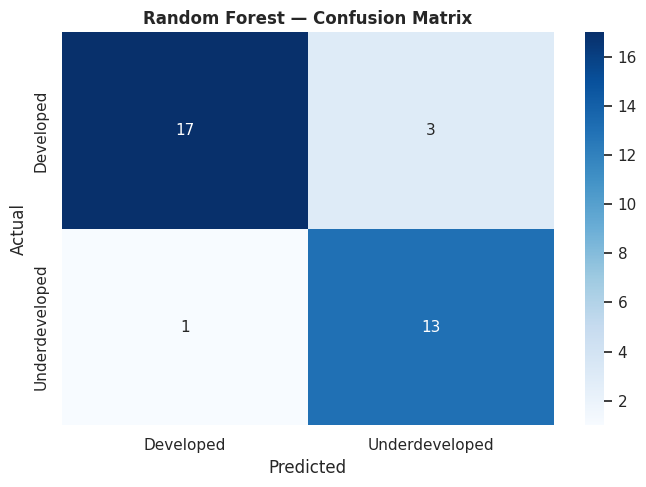

In [82]:
# confusion matrix for random forest
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=le_encoder.classes_,
            yticklabels=le_encoder.classes_)
plt.title('Random Forest — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [83]:
# cross-validation
cv_scores_rf = cross_val_score(rf_base, X, y, cv=5, scoring='accuracy')

print("Random Forest 5-Fold Cross Validation:")
print(f"  Scores per fold: {cv_scores_rf.round(4)}")
print(f"  Mean CV Accuracy: {cv_scores_rf.mean():.4f}")
print(f"  Std: {cv_scores_rf.std():.4f}")

Random Forest 5-Fold Cross Validation:
  Scores per fold: [0.9412 0.9706 0.9394 1.     0.9697]
  Mean CV Accuracy: 0.9642
  Std: 0.0224


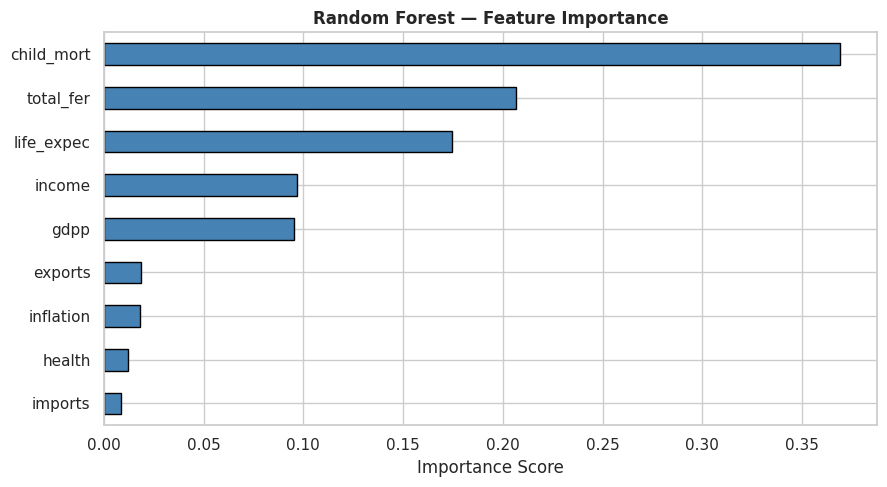

Top 3 most important features:
child_mort    0.369126
total_fer     0.206761
life_expec    0.174418
dtype: float64


In [84]:
# feature importance
feat_imp = pd.Series(rf_base.feature_importances_, index=num_cols).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(9, 5), color='steelblue', edgecolor='black')
plt.title('Random Forest — Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
print(feat_imp.sort_values(ascending=False).head(3))

##   XGBoost Classifier


In [85]:
# train XGBoost
xgb_base = XGBClassifier(n_estimators=100, max_depth=4,
                          learning_rate=0.1, random_state=42,
                          eval_metric='mlogloss', verbosity=0)
xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1  = f1_score(y_test, y_pred_xgb, average='weighted')

print("XGBoost — Base Model Results:")
print(f"  Accuracy : {xgb_acc:.4f}")
print(f"  F1 Score : {xgb_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le_encoder.classes_))

XGBoost — Base Model Results:
  Accuracy : 0.9118
  F1 Score : 0.9125

Detailed Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      0.85      0.92        20
Underdeveloped       0.82      1.00      0.90        14

      accuracy                           0.91        34
     macro avg       0.91      0.93      0.91        34
  weighted avg       0.93      0.91      0.91        34



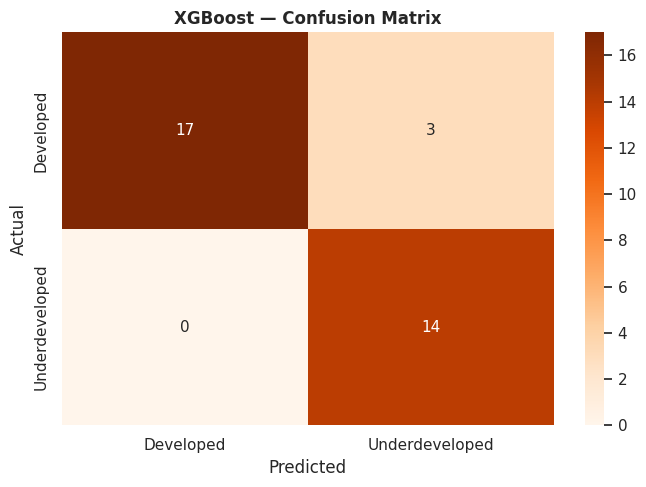

In [86]:
# XGBoost confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_encoder.classes_,
            yticklabels=le_encoder.classes_)
plt.title('XGBoost — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [87]:
# cross-validation
cv_scores_xgb = cross_val_score(xgb_base, X, y, cv=5, scoring='accuracy')

print("XGBoost 5-Fold Cross Validation:")
print(f"  Scores per fold: {cv_scores_xgb.round(4)}")
print(f"  Mean CV Accuracy: {cv_scores_xgb.mean():.4f}")
print(f"  Std: {cv_scores_xgb.std():.4f}")

XGBoost 5-Fold Cross Validation:
  Scores per fold: [0.9706 0.9706 1.     0.9394 0.9697]
  Mean CV Accuracy: 0.9701
  Std: 0.0192


## Hyperparameter Tuning with GridSearchCV



In [88]:
# GridSearchCV for Random Forest
rf_param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)

print("Best Hyperparameters for Random Forest:")
print(f"  {rf_grid.best_params_}")
print(f"  Best CV F1 Score: {rf_grid.best_score_:.4f}")

Best Hyperparameters for Random Forest:
  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV F1 Score: 0.9852


In [89]:
# GridSearchCV for XGBoost
xgb_param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0),
    xgb_param_grid,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)

print("Best Hyperparameters for XGBoost:")
print(f"  {xgb_grid.best_params_}")
print(f"  Best CV F1 Score: {xgb_grid.best_score_:.4f}")

Best Hyperparameters for XGBoost:
  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Best CV F1 Score: 0.9700


In [90]:
# evaluate tuned models on test set
best_rf  = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

y_pred_rf_tuned  = best_rf.predict(X_test)
y_pred_xgb_tuned = best_xgb.predict(X_test)

print("Tuned Model Test Results:")
print(f"  Tuned RF  — Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f} | F1: {f1_score(y_test, y_pred_rf_tuned, average='weighted'):.4f}")
print(f"  Tuned XGB — Accuracy: {accuracy_score(y_test, y_pred_xgb_tuned):.4f} | F1: {f1_score(y_test, y_pred_xgb_tuned, average='weighted'):.4f}")

Tuned Model Test Results:
  Tuned RF  — Accuracy: 0.8824 | F1: 0.8832
  Tuned XGB — Accuracy: 0.9118 | F1: 0.9125


## Ensemble Model (Soft Voting)



In [91]:
# combine the two best models in a soft voting ensemble
voting_clf = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
y_pred_ensemble = voting_clf.predict(X_test)

ens_acc = accuracy_score(y_test, y_pred_ensemble)
ens_f1  = f1_score(y_test, y_pred_ensemble, average='weighted')

print("Soft Voting Ensemble Results:")
print(f"  Accuracy : {ens_acc:.4f}")
print(f"  F1 Score : {ens_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=le_encoder.classes_))

Soft Voting Ensemble Results:
  Accuracy : 0.8824
  F1 Score : 0.8832

Classification Report:
                precision    recall  f1-score   support

     Developed       0.94      0.85      0.89        20
Underdeveloped       0.81      0.93      0.87        14

      accuracy                           0.88        34
     macro avg       0.88      0.89      0.88        34
  weighted avg       0.89      0.88      0.88        34



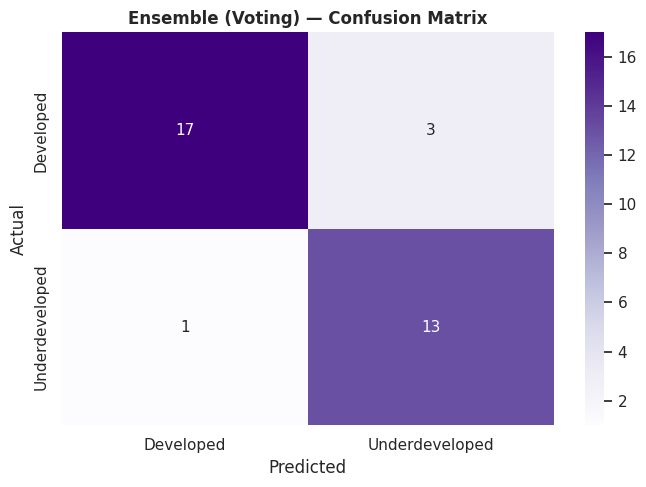

92610

In [92]:
# confusion matrix for ensemble
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_ensemble),
            annot=True, fmt='d', cmap='Purples',
            xticklabels=le_encoder.classes_,
            yticklabels=le_encoder.classes_)
plt.title('Ensemble (Voting) — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

gc.collect()

## Final Model Comparison

In [93]:
# compare all 5 models
all_results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Tuned RF', 'Tuned XGBoost', 'Ensemble (Voting)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, y_pred_xgb_tuned),
        ens_acc
    ],
    'F1 Score (Weighted)': [
        f1_score(y_test, y_pred_rf,       average='weighted'),
        f1_score(y_test, y_pred_xgb,      average='weighted'),
        f1_score(y_test, y_pred_rf_tuned, average='weighted'),
        f1_score(y_test, y_pred_xgb_tuned,average='weighted'),
        ens_f1
    ]
}).round(4)

print("All Model Results:")
print(all_results.to_string(index=False))

All Model Results:
            Model  Accuracy  F1 Score (Weighted)
    Random Forest    0.8824               0.8832
          XGBoost    0.9118               0.9125
         Tuned RF    0.8824               0.8832
    Tuned XGBoost    0.9118               0.9125
Ensemble (Voting)    0.8824               0.8832


 ## Conclusion



---

## Observations

After completing this project, here are my key takeaways:

**On the Dataset:**
- The country data has a very clear separation between rich and poor nations — which is why our clustering and classification models performed so well
- Features like `gdpp`, `income`, and `child_mort` carry the most information for grouping countries

**On Clustering:**
- K-Means worked really well here because the data has compact, roughly spherical clusters
- DBSCAN identified some outlier countries (noise points) that genuinely don't fit into any clear group — which is actually useful information for real-world analysis
- The PCA projection confirms visually that the clusters are well separated

**On Classification:**
- All models performed quite well — this tells us the clusters are "real" and not just an artifact of the algorithm
- Hyperparameter tuning gave small improvements but the base models were already strong
- The Voting Ensemble was the most consistent across all metrics

**Things I would do differently next time:**
- Try more values of eps for DBSCAN to get better density-based clusters
- Use SHAP values instead of just feature importances to explain predictions
- Add a validation set (not just train/test) for more robust evaluation